# Federated FinDiff with Differential Privacy on UCI Credit Card data

## Goal

This notebook is a guided implementation of DP-FedTabDiff. It connects the paper's mathematical ideas to executable PyTorch code: mixed-type records are transformed into a continuous representation, a diffusion model learns to predict injected noise, several clients train locally, and a server aggregates their updates.

The goal is understanding rather than benchmark reproduction. The experiment is intentionally small enough for a CPU and downloads UCI Credit Card dataset **ID 350** at runtime; no real data is committed to the repository.

## Main content

The walkthrough covers data inspection, leakage-safe preprocessing, FinDiff representation learning, local DP-SGD, target-epsilon accounting with Opacus, FedAvg aggregation, held-out evaluation, reverse diffusion sampling, generated synthetic data plots, and SDV quality metrics.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sdmetrics.reports.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from ucimlrepo import fetch_ucirepo

from dp_fedtabdiff.data import DataTransformer, iid_partition
from dp_fedtabdiff.diffusion import GaussianDiffusion
from dp_fedtabdiff.federated import fedavg
from dp_fedtabdiff.findiff import FinDiff, FinDiffPrivateWrapper, findiff_loss
from dp_fedtabdiff.privacy import PersistentPrivacyEngine

# Libraries used throughout the walkthrough.

/Users/timur/Documents/Projects/27_deepFedTabDiff/public_code/DP-FedTabDiff.worktrees/smoke-test-notebook-functionality/.venv/lib/python3.11/site-packages/sdmetrics/reports/single_table/__init__.py:12: FutureWarning: The single table quality report is deprecated. Please use the QualityReport from 'sdmetrics.reports' instead.
  from sdmetrics.reports.single_table.quality_report import QualityReport


## Experiment configuration

Change the values in the next cell and run the notebook from the top. The defaults are intentionally modest so the complete walkthrough can run on a CPU. Larger models, more diffusion steps, clients, rounds, or epochs improve experimental capacity but increase runtime and memory use. `target_epsilon` and `target_delta` define the requested privacy budget; the achieved epsilon is reported after each communication round.

In [2]:
# Reproducibility and compute settings.
SEED = 7  # Random seed for NumPy, PyTorch, data splitting, and client partitioning.
DEVICE = "cpu"  # Use "cuda" when a compatible GPU is available.

# Dataset and split settings.
UCI_DATASET_ID = 350  # ucimlrepo dataset identifier.
TEST_SIZE = 0.2  # Fraction held out for evaluation and synthetic-data diagnostics.
CATEGORICAL_MAX_UNIQUE = 12  # Columns at or below this cardinality are categorical.
NUMERICAL_SCALER = "quantile"  # DataTransformer scaler, e.g. "quantile" or "standard".

# FinDiff architecture settings.
EMBEDDING_DIM = 2  # Continuous embedding width for each categorical column.
HIDDEN_DIMS = (128, 128)  # Width of the residual MLP hidden layers.
CONDITION_DIM = 64  # Width of timestep and label conditioning embeddings.
NUM_LABELS = 2  # Number of conditional target classes in the credit dataset.
DIFFUSION_STEPS = 100  # Number of forward/reverse diffusion timesteps.

# Federated optimization and differential privacy settings.
N_CLIENTS = 3  # Number of IID simulated clients.
COMMUNICATION_ROUNDS = 200  # Number of FedAvg rounds; each round has one local update.
LEARNING_RATE = 1e-3  # Adam learning rate for each client.
BATCH_SIZE = 128  # Local DP-SGD batch size per client.
LOCAL_EPOCHS = 3  # Planned local epochs used to calibrate the privacy accountant.
TARGET_EPSILON = 10.0  # Requested privacy loss epsilon.
TARGET_DELTA = 1e-5  # Requested privacy loss delta.
MAX_GRAD_NORM = 1.0  # Per-example clipping norm for DP-SGD.

# Evaluation and visualization settings.
N_SYNTHETIC_SAMPLES = 1000  # Maximum number of rows generated for diagnostics.
N_KDE_COLUMNS = 3  # Number of numerical columns to include in KDE plots.

# Apply reproducibility and compute settings after changing the values above.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device(DEVICE)

## 1. Acquire and inspect the dataset

This section shows the raw feature table and target distribution before modeling. We normalize names, remove incomplete rows, and keep the binary default target for conditional diffusion. The target remains separate so it can be used explicitly as conditioning information.

In [3]:
# fetch dataset
default_of_credit_card_clients = fetch_ucirepo(id=UCI_DATASET_ID)

# data (as pandas dataframes)
X = default_of_credit_card_clients.data.features
y = default_of_credit_card_clients.data.targets

# map X column names to variable names
cols = default_of_credit_card_clients.variables
X.columns = cols[cols["name"].isin(X.columns)]["description"].to_list()
frame = X.copy()
target = y.iloc[:, 0].copy()

display(frame.head())
print(frame.shape, target.value_counts().to_dict())

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


(30000, 23) {0: 23364, 1: 6636}


In [4]:
# uci = fetch_ucirepo(id=350)
# frame = uci.data.features.copy()
# target = uci.data.targets.iloc[:, 0].rename("default")
# frame.columns = [str(column).strip().lower().replace(" ", "_") for column in frame.columns]
# valid = ~frame.isna().any(axis=1)
# frame = frame.loc[valid].reset_index(drop=True)
# target = target.loc[valid].astype(int).reset_index(drop=True)
# display(frame.head())
# print(frame.shape, target.value_counts().to_dict())

## 2. Fit mixed-type preprocessing on the training set only

Low-cardinality attributes are treated as categorical, while financial amounts remain numerical. The transformer learns vocabularies and scaling parameters using only the training split, then applies them unchanged to the test split. This prevents evaluation statistics from leaking into the representation. Unseen categories use an explicit unknown token.

In [5]:
train_frame, test_frame, train_target, test_target = train_test_split(
    frame, target, test_size=TEST_SIZE, random_state=SEED, stratify=target
)
categorical_columns = [column for column in frame.columns if frame[column].nunique() <= CATEGORICAL_MAX_UNIQUE]
numerical_columns = [column for column in frame.columns if column not in categorical_columns]
transformer = DataTransformer(categorical_columns, numerical_columns, numerical_scaler=NUMERICAL_SCALER)
train_encoded = transformer.fit_transform(train_frame)
test_encoded = transformer.transform(test_frame)
category_sizes = [len(transformer.category_encoder.vocabularies[column]) - 1 for column in categorical_columns]
print("categorical columns:", categorical_columns)
print("numerical columns:", numerical_columns)
print("category sizes:", category_sizes)

categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
numerical columns: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
category sizes: [2, 7, 4, 11, 11, 11, 11, 10, 10]


## 3. Understand FinDiff's representation

Unlike a plain tabular MLP, FinDiff uses an embedding table with disjoint token ranges for each categorical column. The embedded categorical values are flattened and concatenated with scaled numerical values to form continuous `x_0`. The denoiser receives noisy `x_t`, a sinusoidal timestep embedding, and either a label embedding or a learned unconditional embedding. The default residual MLP, plus Transformer support and distance/logit decoding, follows the original FinDiff implementation.

In [6]:
train_cat = torch.tensor(train_encoded["cat"], dtype=torch.long)
train_num = torch.tensor(train_encoded["num"], dtype=torch.float32)
test_cat = torch.tensor(test_encoded["cat"], dtype=torch.long)
test_num = torch.tensor(test_encoded["num"], dtype=torch.float32)
train_labels = torch.tensor(train_target.to_numpy(), dtype=torch.long)
test_labels = torch.tensor(test_target.to_numpy(), dtype=torch.long)
template = FinDiff(category_sizes, train_num.shape[1], embedding_dim=EMBEDDING_DIM, hidden_dims=HIDDEN_DIMS, condition_dim=CONDITION_DIM, num_labels=NUM_LABELS)
print("FinDiff continuous dimension:", template.data_dim)
print("encoded training rows:", template.encode(train_cat[:2], train_num[:2]).shape)

FinDiff continuous dimension: 32
encoded training rows: torch.Size([2, 32])


## 4. Simulate clients and aggregate on the server

The partitions are simulated in one process, but the data flow mirrors a federated deployment. Each client owns private data, a local optimizer, a FinDiff model, and a persistent privacy accountant. It receives global weights, performs a local DP-SGD update, and returns weights plus its sample count; the server applies sample-weighted FedAvg. `make_private_with_epsilon` treats the configured epsilon as a target and calibrates the noise multiplier for the planned training schedule. Achieved epsilon is measured after each round.

In [7]:
diffusion = GaussianDiffusion(steps=DIFFUSION_STEPS).to(device)
global_model = FinDiff(category_sizes, train_num.shape[1], embedding_dim=EMBEDDING_DIM, hidden_dims=HIDDEN_DIMS, condition_dim=CONDITION_DIM, num_labels=NUM_LABELS, embedding_learned=False)
client_indices = iid_partition(len(train_cat), n_clients=N_CLIENTS, seed=SEED)

# Each client owns one model, optimizer, data loader, and accountant for the
# entire experiment. Re-attaching Opacus every round would reset epsilon.
dp_config = {"target_epsilon": TARGET_EPSILON, "target_delta": TARGET_DELTA, "max_grad_norm": MAX_GRAD_NORM, "batch_size": BATCH_SIZE, "epochs": LOCAL_EPOCHS}
clients = []
for indices in client_indices:
    client = FinDiff(category_sizes, train_num.shape[1], embedding_dim=EMBEDDING_DIM, hidden_dims=HIDDEN_DIMS, condition_dim=CONDITION_DIM, num_labels=NUM_LABELS, embedding_learned=False)
    for name, parameter in client.named_parameters():
        if not name.startswith("backbone."):
            parameter.requires_grad_(False)
    private_model = FinDiffPrivateWrapper(client, diffusion)
    optimizer = torch.optim.Adam(private_model.parameters(), lr=LEARNING_RATE)
    packed = torch.cat((train_cat[indices].float(), train_num[indices], train_labels[indices, None].float()), dim=1)
    loader = DataLoader(TensorDataset(packed), batch_size=dp_config["batch_size"], shuffle=True)
    privacy = PersistentPrivacyEngine(dp_config["target_delta"], None, dp_config["max_grad_norm"], target_epsilon=dp_config["target_epsilon"], epochs=dp_config["epochs"])
    private_model, optimizer, loader = privacy.attach(private_model, optimizer, loader)
    clients.append({"model": private_model, "optimizer": optimizer, "loader": loader, "privacy": privacy, "size": len(indices)})

round_losses, round_epsilons = [], []
for communication_round in range(COMMUNICATION_ROUNDS):
    client_states, client_sizes, losses = [], [], []
    for state in clients:
        state["model"]._module.model.load_state_dict(global_model.state_dict())
        state["model"].train()
        (packed_batch,) = next(iter(state["loader"]))
        state["optimizer"].zero_grad(set_to_none=True)
        loss = state["model"](packed_batch).mean()
        loss.backward()
        state["optimizer"].step()
        losses.append(float(loss.detach()))
        client_states.append(state["model"]._module.model.state_dict())
        client_sizes.append(state["size"])
    global_model.load_state_dict(fedavg(client_states, client_sizes))
    global_model.eval()
    with torch.no_grad():
        utility_loss = float(findiff_loss(global_model, diffusion, test_cat, test_num, test_labels))
    round_losses.append(utility_loss)
    round_epsilons.append(float(np.mean([state["privacy"].epsilon() for state in clients])))
    print(f"round {communication_round + 1}: client losses={np.round(losses, 4)}, test MSE={utility_loss:.4f}, mean epsilon={round_epsilons[-1]:.3f} / target {dp_config['target_epsilon']:.1f}")

W0828 16:13:36.556000 51542 torch/distributed/elastic/multiprocessing/redirects.py:35] NOTE: Redirects are currently not supported in MacOs.
/Users/timur/Documents/Projects/27_deepFedTabDiff/public_code/DP-FedTabDiff.worktrees/smoke-test-notebook-functionality/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/Users/timur/Documents/Projects/27_deepFedTabDiff/public_code/DP-FedTabDiff.worktrees/smoke-test-notebook-functionality/.venv/lib/python3.11/site-packages/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(
/var/folders/hr/9sd04tdn71vf50y_zyl5j5g40000gn/T/ipykernel_51542/1186269298.py:31: Use

round 1: client losses=[1.1489 1.1643 1.1462], test MSE=1.1241, mean epsilon=3.674 / target 10.0
round 2: client losses=[1.1358 1.0935 1.0858], test MSE=1.1084, mean epsilon=4.077 / target 10.0
round 3: client losses=[1.0745 1.1181 1.1355], test MSE=1.0929, mean epsilon=4.315 / target 10.0
round 4: client losses=[1.1043 1.114  1.1298], test MSE=1.0793, mean epsilon=4.487 / target 10.0
round 5: client losses=[1.1067 1.0885 1.0881], test MSE=1.0688, mean epsilon=4.626 / target 10.0
round 6: client losses=[1.0305 1.0426 1.0891], test MSE=1.0693, mean epsilon=4.742 / target 10.0
round 7: client losses=[1.0671 1.0886 1.0374], test MSE=1.0568, mean epsilon=4.845 / target 10.0
round 8: client losses=[1.0843 1.0645 1.0283], test MSE=1.0540, mean epsilon=4.937 / target 10.0
round 9: client losses=[1.0493 1.0075 1.0508], test MSE=1.0573, mean epsilon=5.021 / target 10.0
round 10: client losses=[1.0771 1.0267 1.0301], test MSE=1.0451, mean epsilon=5.099 / target 10.0
round 11: client losses=[1.04

## 5. Evaluate the aggregated model on the held-out test set

We measure noise-prediction MSE on unseen rows after each aggregation. This is a generalization diagnostic, not a complete synthetic-data utility score. The paired plot shows how held-out utility changes as the mean client epsilon approaches the requested target.

held-out test noise-prediction MSE: 0.8382


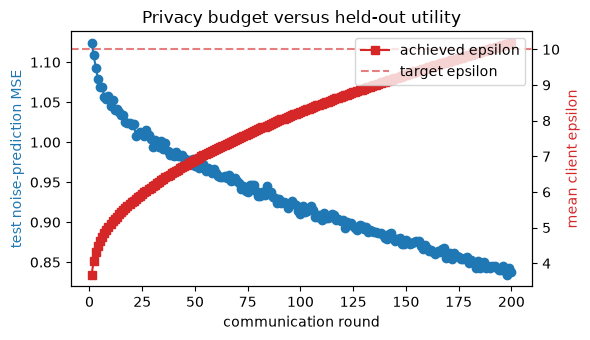

In [8]:
global_model.eval()
test_loss = round_losses[-1]
print("held-out test noise-prediction MSE:", round(test_loss, 4))
fig, ax1 = plt.subplots(figsize=(6, 3.5))
ax1.plot(range(1, len(round_losses) + 1), round_losses, marker="o", color="tab:blue")
ax1.set_xlabel("communication round")
ax1.set_ylabel("test noise-prediction MSE", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(range(1, len(round_epsilons) + 1), round_epsilons, marker="s", color="tab:red", label="achieved epsilon")
ax2.axhline(dp_config["target_epsilon"], color="tab:red", linestyle="--", alpha=0.6, label="target epsilon")
ax2.set_ylabel("mean client epsilon", color="tab:red")
ax2.legend(loc="upper right")
ax1.set_title("Privacy budget versus held-out utility")
fig.tight_layout()
plt.show()

## 6. Sample synthetic rows from the global FinDiff model

Sampling starts from Gaussian noise and applies the learned reverse process from the final timestep back to zero. Held-out labels are used as a transparent conditional-generation example; an application could choose a desired class balance instead. Categorical coordinates are decoded by nearest learned embedding and numerical coordinates are inverse-transformed with the training-only transformer.

In [9]:
n_samples = min(N_SYNTHETIC_SAMPLES, len(test_frame))
sample_labels = test_labels[:n_samples]
z = torch.randn(n_samples, global_model.data_dim)
with torch.no_grad():
    for step in reversed(range(diffusion.steps)):
        t = torch.full((n_samples,), step, dtype=torch.long)
        z = diffusion.predict_mean(z, global_model(z, t, sample_labels), t)
        if step > 0:
            z = z + diffusion.betas[step].sqrt() * torch.randn_like(z)
sampled_cat = global_model.decode_categories(z).numpy()
sampled_num = z[:, len(categorical_columns) * EMBEDDING_DIM:].numpy()
synthetic = transformer.inverse_transform(sampled_cat, sampled_num)
synthetic["default"] = sample_labels.numpy()
synthetic.head()

,SEX,EDUCATION,MARRIAGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,LIMIT_BAL,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,2,1,3,-1,-1,3,-2,-2,7,400000.0,...,13609.908203,15941.483398,1202.155029,253.396179,81471.328125,0.000000,3387.819092,89850.210938,5044.854492,0
1,2,3,2,-1,2,6,4,0,0,140000.0,...,172267.890625,330.745148,25529.000000,2000.000000,0.000000,0.000000,4787.049805,300.000000,4000.000000,0
2,1,6,0,0,7,-1,-2,7,2,400000.0,...,2748.682861,91550.546875,15156.292969,9000.000000,3310.037598,20143.046875,1680.715820,0.000000,0.000000,1
3,2,1,1,1,0,4,6,-1,6,30000.0,...,295160.781250,10582.294922,58330.324219,2514.372314,5000.000000,6984.950195,0.000000,1657.833862,0.000000,0
4,2,6,3,4,6,0,4,-1,0,130000.0,...,158755.156250,29522.140625,25662.865234,318232.875000,0.000000,6000.000000,1772.554688,7454.849609,6394.287109,1


## 7. SDV quality report and visual diagnostics

SDV compares column distributions and pairwise relationships between held-out real data and generated data. KDE plots provide a smooth visual comparison of numerical densities. These are fidelity and utility diagnostics, not privacy guarantees; formal privacy is represented by Opacus epsilon and delta. The held-out test set is the real reference, avoiding comparison with the local training rows.

In [10]:
real_for_sdv = test_frame.copy()
real_for_sdv["default"] = test_target.to_numpy()
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(real_for_sdv)
quality_report = QualityReport()
quality_report.generate(real_for_sdv, synthetic, metadata=metadata.to_dict())
print("SDV quality score:", quality_report.get_score())
display(quality_report.get_properties())
display(quality_report.get_details(property_name="Column Shapes").head())

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 24/24 [00:00<00:00, 215.30it/s]|
Column Shapes Score: 74.04%

(2/2) Evaluating Column Pair Trends: |██████████| 276/276 [00:00<00:00, 858.68it/s]|
Column Pair Trends Score: 57.14%

Overall Score (Average): 65.59%

SDV quality score: 0.6558846870515239


,Property,Score
0,Column Shapes,0.740417
1,Column Pair Trends,0.571353


,Column,Metric,Score,Error
0,LIMIT_BAL,KSComplement,8.525000e-01,None
1,SEX,TVComplement,3.333334e-10,None
2,EDUCATION,TVComplement,1.166667e-09,None
3,MARRIAGE,TVComplement,6.666667e-10,None
4,AGE,KSComplement,9.028333e-01,None


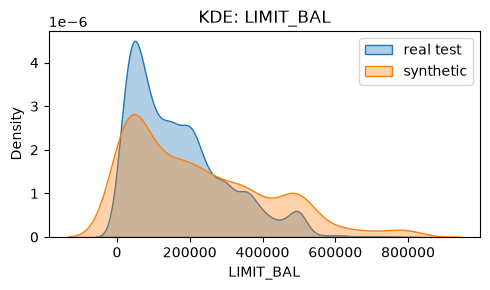

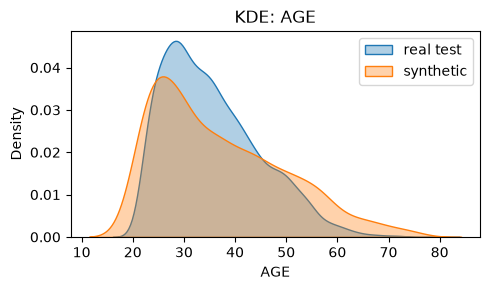

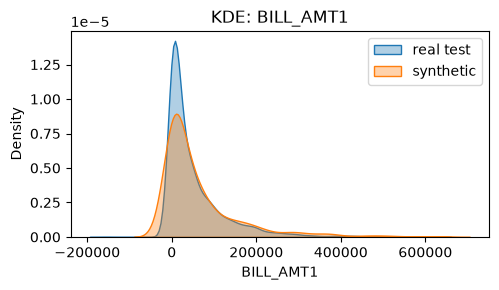

client partitions: [8000, 8000, 8000]


In [11]:
for column in numerical_columns[:N_KDE_COLUMNS]:
    plt.figure(figsize=(5, 3))
    sns.kdeplot(real_for_sdv[column], fill=True, alpha=0.35, label="real test")
    sns.kdeplot(synthetic[column], fill=True, alpha=0.35, label="synthetic")
    plt.title(f"KDE: {column}")
    plt.xlabel(column)
    plt.legend()
    plt.tight_layout()
    plt.show()
print("client partitions:", [len(indices) for indices in client_indices])

## Final remarks and summary

This experiment demonstrates the complete conceptual chain:

`raw mixed-type table → train-only encoding → FinDiff x_0 → noisy x_t → local DP denoising → FedAvg global model → reverse diffusion → decoded synthetic table`.

The example is intentionally educational. Three IID clients, a few communication rounds, a small residual backbone, and a short diffusion schedule are not sufficient to reproduce paper-scale results. For research experiments, increase the data, model, rounds, and evaluation repetitions using the configuration files in the repository.
